In [111]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [ ]:
inputs = xr.open_zarr("/glade/work/milesep/convective_outlook_ml/train_inputs_slgt_small_glade.zarr")

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\backends\plugins.py:139: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\backends\plugins.py:139: RuntimeWarning: 'h5netcdf' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\backends\plugins.py:139: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [ ]:
inputs.data_vars

<xarray.Dataset>
Dimensions:                       (latitude: 16, longitude: 21, day: 28,
                                   tod: 4, level: 5)
Coordinates:
  * day                           (day) datetime64[ns] 2020-01-10 ... 2023-06-15
  * latitude                      (latitude) float32 45.0 44.0 ... 31.0 30.0
  * level                         (level) int64 925 850 700 500 300
  * longitude                     (longitude) float32 255.0 256.0 ... 275.0
  * tod                           (tod) int64 0 6 12 18
Data variables: (12/13)
    10m_u_component_of_wind       (latitude, longitude, day, tod) float32 ...
    10m_v_component_of_wind       (latitude, longitude, day, tod) float32 ...
    2m_dewpoint_temperature       (latitude, longitude, day, tod) float32 ...
    2m_temperature                (latitude, longitude, day, tod) float32 ...
    geopotential                  (level, latitude, longitude, day, tod) float32 ...
    geopotential_at_surface       (latitude, longitude, day, tod) float32 ...
    ...                            ...
    specific_humidity             (level, latitude, longitude, day, tod) float32 ...
    temperature                   (level, latitude, longitude, day, tod) float32 ...
    toa_incident_solar_radiation  (latitude, longitude, day, tod) float32 ...
    u_component_of_wind           (level, latitude, longitude, day, tod) float32 ...
    v_component_of_wind           (level, latitude, longitude, day, tod) float32 ...
    vertical_velocity             (level, latitude, longitude, day, tod) float32 ...

In [38]:
# -----------------------------
# load + average folds
# -----------------------------

def load_folds(base_dir, n_folds=5):
    folds = []
    for f in range(n_folds):
        path = os.path.join(base_dir, f"fold_{f}", "ig_results.pt")
        folds.append(torch.load(path, map_location="cpu"))
    return folds


def average_folds(folds, scalars, K=9):
    out = {}

    for s in scalars:
        chan = sum(f["channel"][s] for f in folds) / len(folds)
        spat = sum(f["spatial"][s] for f in folds) / len(folds)
        temp = sum(f["temporal"][s] for f in folds) / len(folds)

        out[s] = {"channel": chan, "spatial": spat, "temporal": temp}

    return out



In [39]:
scalars = ["mean", "sigma", "p_gt_2", "p_lt_-2"]
base_dir = "results/ig/cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL"

folds = load_folds(base_dir)
avg = average_folds(folds, scalars)

In [ ]:
#channel avgs: order var1 (925), var2(850), etc.. levels are [925 850 700 500 300]. variable order is: 

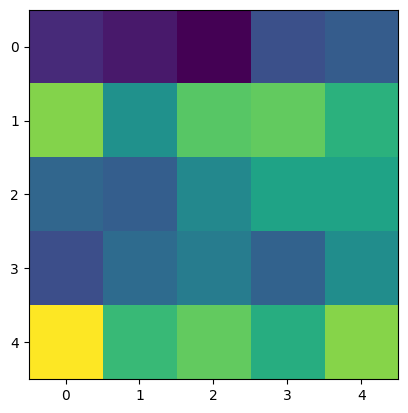

In [110]:
plt.imshow(channel_avgs[6][4:].reshape(5, 5))

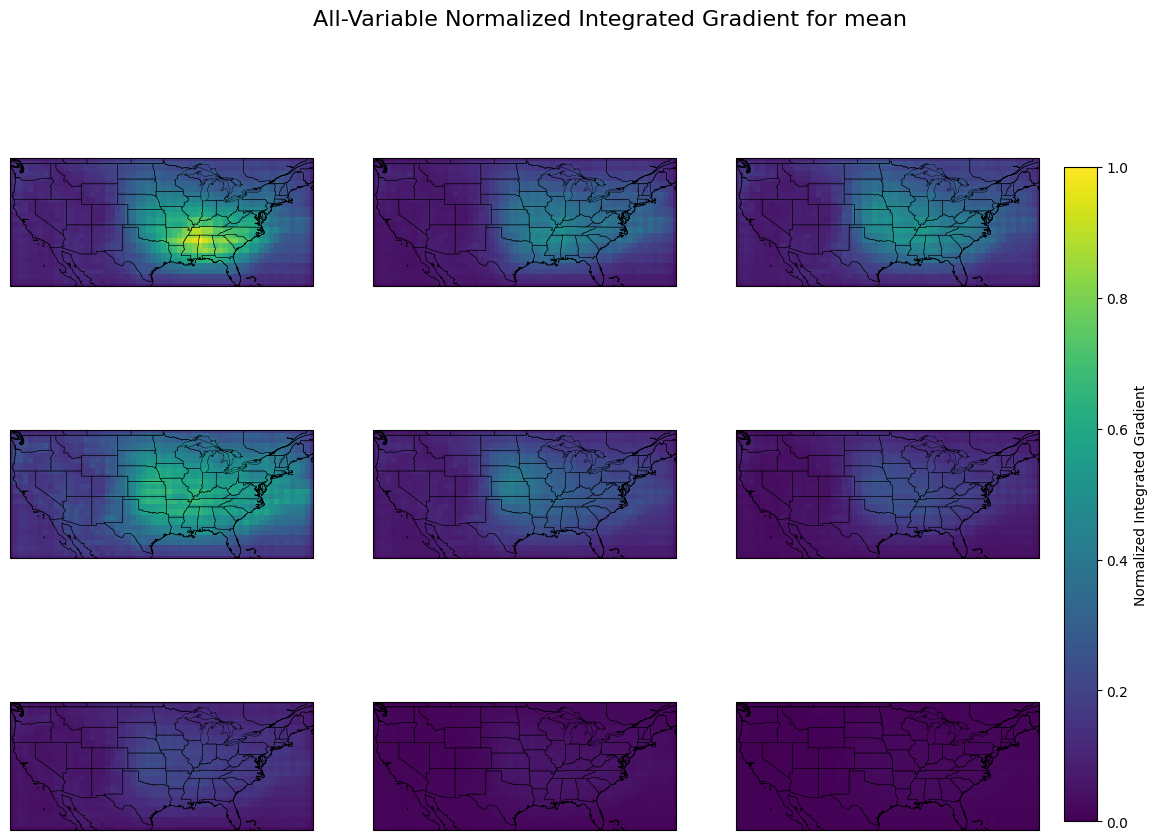

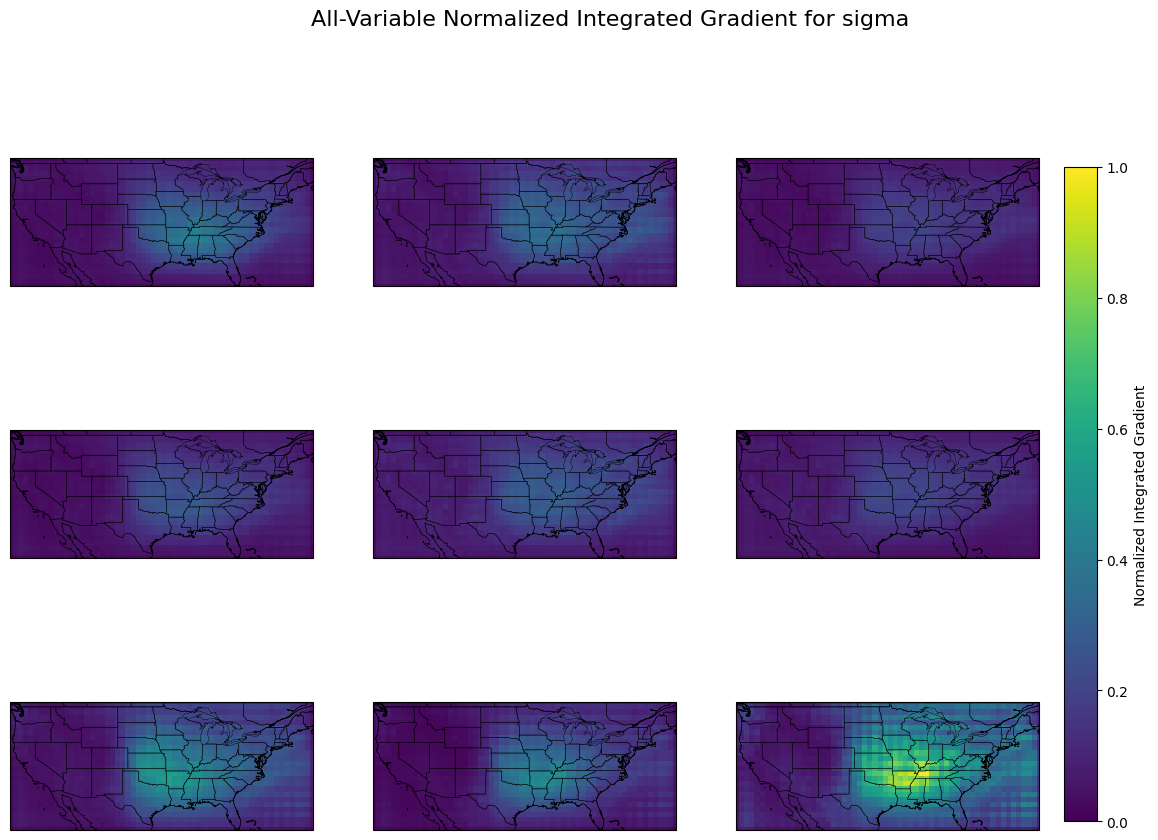

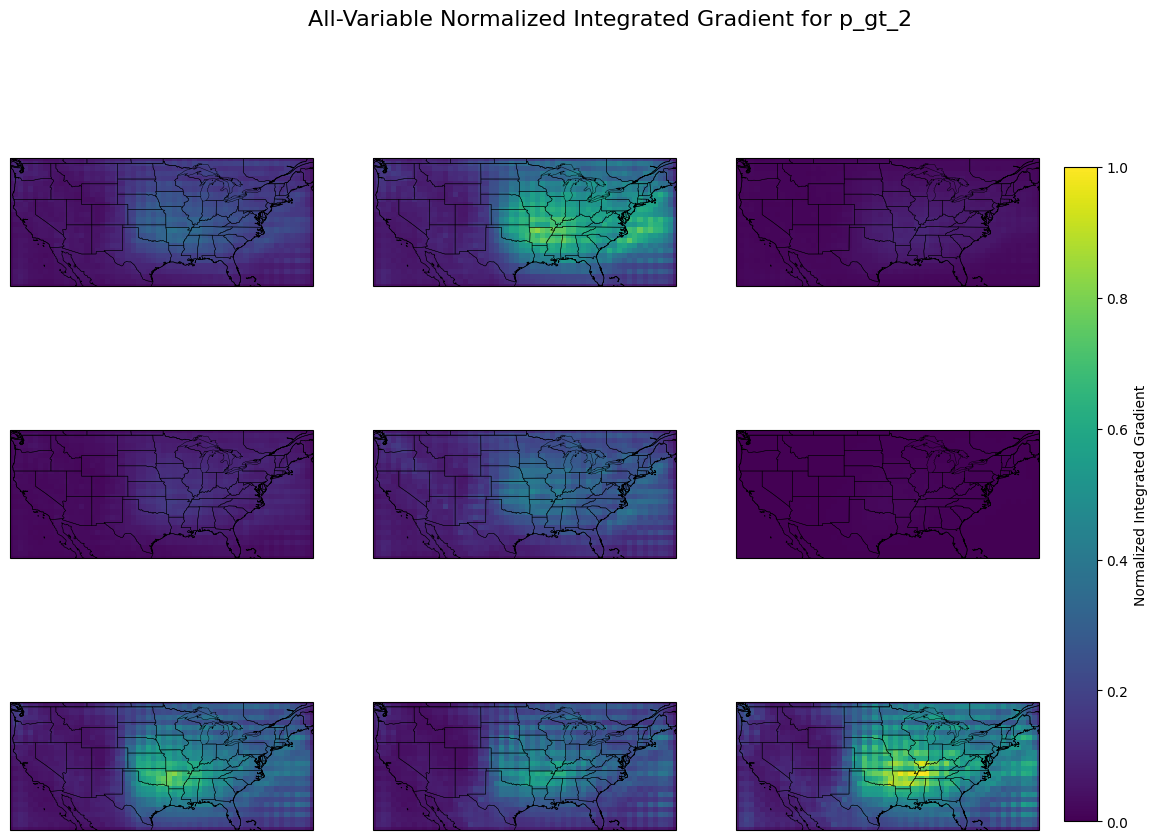

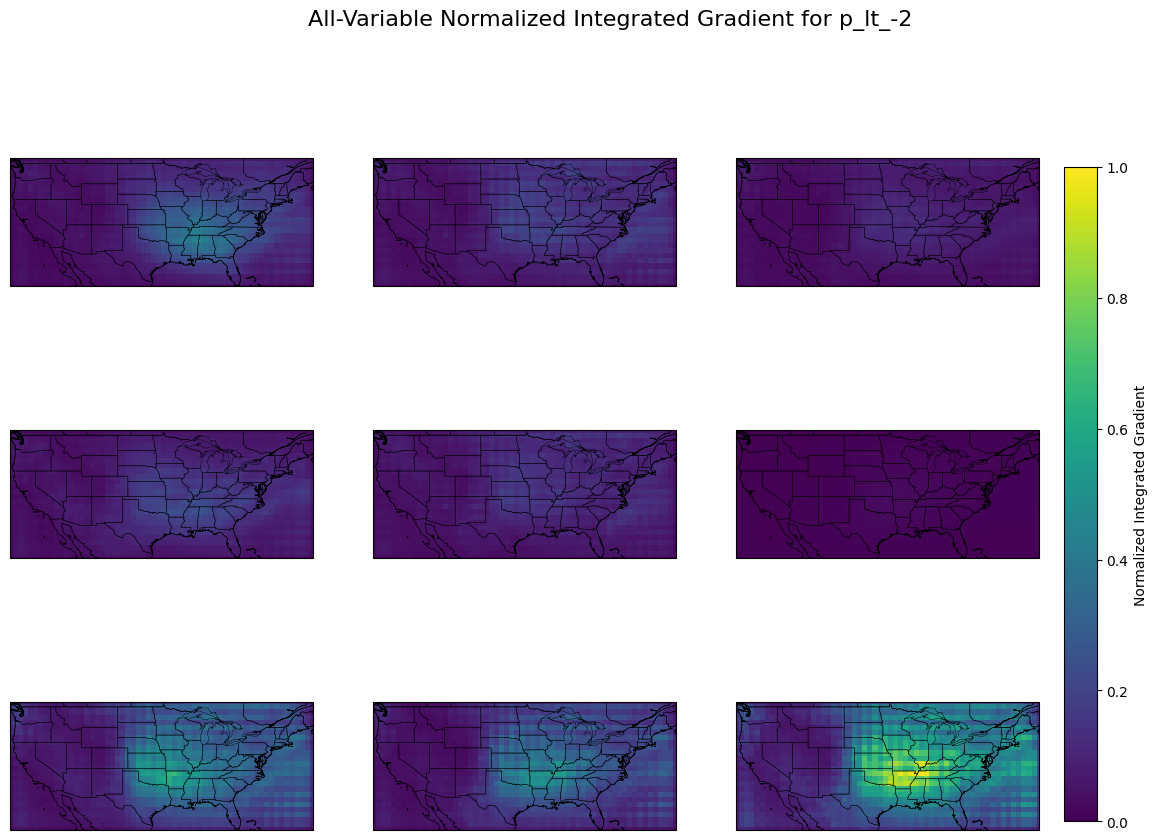

In [ ]:
lats = np.arange(50, 24, -1)      # 50 down to 25
lons = np.arange(-125, -65, 1)    # -125 to -66

for target in scalars:
    a = avg[target]
    channel_avgs = a['channel']




    
    spatial_avgs = a['spatial']
    
    # global color scale across all panels
    smin = torch.min(spatial_avgs)
    smax = torch.max(spatial_avgs)
    spatial_avgs = (spatial_avgs - smin) / (smax - smin)

    # 3x3 layout for 9 panels
    fig, axes = plt.subplots(
        3, 3,
        figsize=(16, 10),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    axes = axes.flatten()

    for i, ax in enumerate(axes):

        data = spatial_avgs[i]

        ax.set_extent([-125, -66, 25, 50], crs = ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)

        mesh = ax.pcolormesh(
            lons,
            lats,
            data,
            cmap='viridis',
            shading='auto',
            vmin=0,
            vmax=1,
            transform=ccrs.PlateCarree()
        )

    # single shared colorbar
    cbar = fig.colorbar(
        mesh,
        ax=axes,
        orientation='vertical',
        shrink=0.85,
        pad=0.02
    )

    cbar.set_label("Normalized Integrated Gradient")

    fig.suptitle(f'All-Variable Normalized Integrated Gradient for {target}', fontsize=16)
    plt.show()

    temporal_avgs = a['temporal']
    